In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/iris/Iris.csv
/kaggle/input/datasets/uciml/iris/database.sqlite


In [3]:
df = pd.read_csv('/kaggle/input/datasets/uciml/iris/Iris.csv')

In [4]:
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
24,25,4.8,3.4,1.9,0.2,Iris-setosa
121,122,5.6,2.8,4.9,2.0,Iris-virginica
140,141,6.7,3.1,5.6,2.4,Iris-virginica
38,39,4.4,3.0,1.3,0.2,Iris-setosa


In [5]:
df.shape

(150, 6)

### Dataset Information
* Has **150 rows** and **6 columns**
* **Species**: contains **three distinct** categories:
  * `Iris-setosa`, `Iris-virginica`, and `Iris-versicolor`
* **Id**
  * unique identifier
* **SepalLengthCm**
  * `numerical` column
* **PetalLengthCm**
  * `numerical` column
* **PetalWidthCm**
  * `numerical` column
    

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [7]:
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])

In [8]:
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,2
79,80,5.7,2.6,3.5,1.0,1
87,88,6.3,2.3,4.4,1.3,1
127,128,6.1,3.0,4.9,1.8,2
128,129,6.4,2.8,5.6,2.1,2


In [9]:
# Features and Target Selection
X = df.drop(columns = ['Species'], axis = 1)
y = df['Species']

In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 5), (30, 5), (120,), (30,))

In [11]:
logistic_reg = LogisticRegression()
decision_tree = DecisionTreeClassifier()

In [12]:
logistic_reg.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [13]:
y_pred1 = logistic_reg.predict(X_test)
y_pred2 = decision_tree.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
print(f'Logisitic Regression Accuracy Score: {accuracy_score(y_test,y_pred1)}')
print(f'Decision Tree Accuracy Score: {accuracy_score(y_test,y_pred2)}')

Logisitic Regression Accuracy Score: 1.0
Decision Tree Accuracy Score: 1.0


Confusion Matrix for Logistic Regression:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]



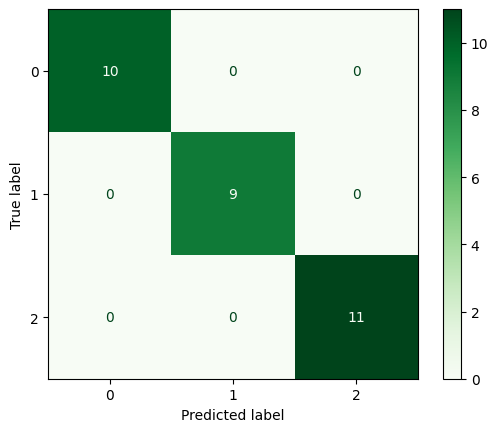

In [15]:
cm = confusion_matrix(y_test, y_pred1, labels = logistic_reg.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels = logistic_reg.classes_)

print(f'Confusion Matrix for Logistic Regression:\n {cm}')
print()

disp.plot(cmap = plt.cm.Greens)
plt.show()

Confusion Matrix for Decision Tree:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]



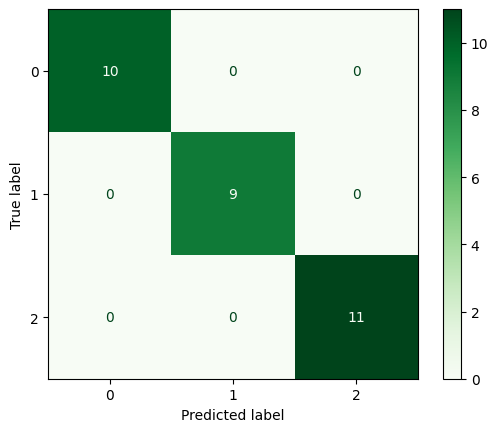

In [16]:
cm = confusion_matrix(y_test, y_pred2, labels = logistic_reg.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels = logistic_reg.classes_)

print(f'Confusion Matrix for Decision Tree:\n {cm}')
print()

disp.plot(cmap = plt.cm.Greens)
plt.show()

In [17]:
result = pd.DataFrame()
result['Acutal Result'] = y_test
result['Logistic Prediction'] = y_pred1
result['Decision Tree Prediction'] = y_pred2
result.sample(10)

,Acutal Result,Logistic Prediction,Decision Tree Prediction
76,1,1,1
108,2,2,2
69,1,1,1
82,1,1,1
78,1,1,1
45,0,0,0
12,0,0,0
104,2,2,2
55,1,1,1
9,0,0,0


In [18]:
precisions = {
    'Precision Type':['None', 'Macro', 'Wieghted'],
    'Logistic Regression':[
        precision_score(y_test, y_pred1, average = None),
        precision_score(y_test, y_pred1, average = 'macro'),
        precision_score(y_test, y_pred1, average = 'weighted')  
    ],
    'Decision Tree':[
        precision_score(y_test, y_pred2, average = None),
        precision_score(y_test, y_pred2, average = 'macro'),
        precision_score(y_test, y_pred2, average = 'weighted')
        
    ]
}
comparison_precision = pd.DataFrame (precisions).set_index('Precision Type')
comparison_precision

,Logistic Regression,Decision Tree
Precision Type,,
None,"[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]"
Macro,1.0,1.0
Wieghted,1.0,1.0


In [19]:
recalls = {
    'Recall Type':['None', 'Macro', 'Wieghted'],
    'Logistic Regression':[
        precision_score(y_test, y_pred1, average = None),
        precision_score(y_test, y_pred1, average = 'macro'),
        precision_score(y_test, y_pred1, average = 'weighted')  
    ],
    'Decision Tree':[
        precision_score(y_test, y_pred2, average = None),
        precision_score(y_test, y_pred2, average = 'macro'),
        precision_score(y_test, y_pred2, average = 'weighted')
        
    ]
}
comparison_recall = pd.DataFrame (recalls).set_index('Recall Type')
comparison_recall

,Logistic Regression,Decision Tree
Recall Type,,
None,"[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]"
Macro,1.0,1.0
Wieghted,1.0,1.0


In [20]:
f_1 = {
    'F1 Type':['None', 'Macro', 'Wieghted'],
    'Logistic Regression':[
        precision_score(y_test, y_pred1, average = None),
        precision_score(y_test, y_pred1, average = 'macro'),
        precision_score(y_test, y_pred1, average = 'weighted')  
    ],
    'Decision Tree':[
        precision_score(y_test, y_pred2, average = None),
        precision_score(y_test, y_pred2, average = 'macro'),
        precision_score(y_test, y_pred2, average = 'weighted')
        
    ]
}
comparison_f1 = pd.DataFrame (f_1).set_index('F1 Type')
comparison_f1

,Logistic Regression,Decision Tree
F1 Type,,
None,"[1.0, 1.0, 1.0]","[1.0, 1.0, 1.0]"
Macro,1.0,1.0
Wieghted,1.0,1.0


In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred1))
print()
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

